# Configs

In [1]:
import random


random.seed(27)

splitPartCount = 5
splitSeed = 27
hoursPerWindow = 1

# Load data

In [2]:
from utils.prepare_data import getMonitoredPatients
from pandas import Timedelta


patients = getMonitoredPatients()
patients.removePatientAkiEarly(Timedelta(hours=12))

print("Total ", len(patients))
print("AKI ", sum([1 for p in patients if p.akdPositive]))
print("Ratio ", sum([1 for p in patients if p.akdPositive]) / len(patients))

Total  1124
AKI  392
Ratio  0.3487544483985765


# Model

In [3]:
import tabpfn
import torch
import torch.nn as nn
import math


class PositionalEncoding(nn.Module):
    def __init__(self, model_dim, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, model_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, model_dim, 2).float() * (-math.log(10000.0) / model_dim)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: [batch_size, seq_len, model_dim]
        x = x + self.pe[: x.size(1)]
        return x


class TimeSeriesTransformerWithMLP(nn.Module):
    def __init__(
        self,
        n_staticFeat,
        n_timeFeat,
        model_dim,
        transformer_layers=4,
        nhead=8,
        hidden_dim=128,
        use_cls=True,
    ):
        super().__init__()
        self.use_cls = use_cls
        self.model_dim = model_dim

        # Project input features through an MLP
        self.mlp = nn.Sequential(
            nn.Linear(n_timeFeat, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, model_dim)
        )

        # Positional encoding
        self.pos_encoder = PositionalEncoding(model_dim)

        # [CLS] token
        if use_cls:
            self.cls_token = nn.Parameter(torch.zeros(1, 1, model_dim))
            nn.init.trunc_normal_(self.cls_token, std=0.02)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim, nhead=nhead, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=transformer_layers
        )

        # static features projection
        self.static_proj = nn.Linear(n_staticFeat, model_dim)
        
        # connect static and time features
        self.merge = nn.Linear(model_dim + model_dim, model_dim)

    def forward(self, staticX, timeX):
        # Apply MLP: [batch, n_time, model_dim]
        x = self.mlp(timeX)

        # Optionally prepend CLS token
        if self.use_cls:
            batch_size = x.size(0)
            cls = self.cls_token.expand(batch_size, -1, -1)  # [batch, 1, model_dim]
            x = torch.cat([cls, x], dim=1)

        # Add positional encoding
        x = self.pos_encoder(x)

        # Transformer
        x = self.transformer(x)  # [batch, seq_len(+1), model_dim]

        # Extract CLS token embedding or pool
        if self.use_cls:
            cls_embedding = x[:, 0, :]  # [batch, model_dim]
        else:
            cls_embedding = x.mean(dim=1)  # Average pooling
            
        # Project static features
        static_embedding = self.static_proj(staticX)
        # Merge static and time features
        merged_embedding = torch.cat((cls_embedding, static_embedding), dim=1)
        
        out = self.merge(merged_embedding)  # [batch, model_dim]

        return out

class TransformerPredictor(nn.Module):

    def __init__(
        self,
        n_staticFeat,
        n_timeFeat,
        model_dim,
        transformer_layers=4,
        nhead=8,
        hidden_dim=128,
    ):
        super().__init__()

        self.transformer = TimeSeriesTransformerWithMLP(
            n_staticFeat=n_staticFeat,
            n_timeFeat=n_timeFeat,
            model_dim=model_dim,
            transformer_layers=transformer_layers,
            nhead=nhead,
            hidden_dim=hidden_dim,
            use_cls=True,
        )
        
        self.predictor = nn.Sequential(
            nn.Linear(model_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),  # Binary classification
        )

    def forward(self, staticX, timeX):
        # Get the transformer output
        transformer_output = self.transformer(staticX, timeX)
        
        transformer_output = torch.relu(transformer_output)  # Apply ReLU activation
        
        # Pass through predictor
        prediction = self.predictor(transformer_output)
        
        return prediction
        

# Train and eval

## Functions

## Cross-val

In [ ]:
%%capture
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc,
)
from utils.class_voter import combineProbas
from utils.dl_train_test import infer, train
from utils.prepare_data import (
    DeepLearningDataPreparer,
    trainValTestPatients,
)
import numpy as np


accuracy_score_list = []
precision_score_list = []
recall_score_list = []
auc_score_list = []
specificity_score_list = []
sensitivity_score_list = []
auc_pr_list = []

tabpfn_accuracy_score_list = []
tabpfn_precision_score_list = []
tabpfn_recall_score_list = []
tabpfn_auc_score_list = []
tabpfn_specificity_score_list = []
tabpfn_sensitivity_score_list = []
tabpfn_auc_pr_list = []

train_loss_list = []
val_loss_list = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batchSize = 64

for i, (trainValGenerator, testPatients) in enumerate(
    trainValTestPatients(patients, splitSeed)
):
    contextXs = []
    contextYs = []
    embeddings = []
    probas = []
    for ii, (trainPatients, valPatients) in enumerate(trainValGenerator):
        preparer = DeepLearningDataPreparer(
            hoursPerWindows=hoursPerWindow,
            fromHour=0,
            toHour=12,
        )

        (
            (npTrainX, staticTrainX, trainY),
            (npValX, staticValX, valY),
            (npTestX, staticTestX, testY),
        ) = preparer.trainValTest(trainPatients, valPatients, testPatients)

        # create data loader
        trainLoader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(
                torch.tensor(staticTrainX).float(),
                torch.tensor(npTrainX).float(),
                torch.tensor(trainY).unsqueeze(1).float(),
            ),
            batch_size=batchSize,
            pin_memory=True,
            shuffle=True,
        )
        valLoader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(
                torch.tensor(staticValX).float(),
                torch.tensor(npValX).float(),
                torch.tensor(valY).unsqueeze(1).float(),
            ),
            batch_size=batchSize,
            pin_memory=True,
            shuffle=False,
        )
        testLoader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(
                torch.tensor(staticTestX).float(),
                torch.tensor(npTestX).float(),
                torch.tensor(testY).unsqueeze(1).float(),
            ),
            batch_size=batchSize,
            pin_memory=True,
            shuffle=False,
        )

        n_staticFeat = staticTrainX.shape[1]
        n_timeFeat = npTrainX.shape[2]

        transformer = TransformerPredictor(
            n_staticFeat=n_staticFeat,
            n_timeFeat=n_timeFeat,
            model_dim=96,
        )

        criterion = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.Adam(transformer.parameters(), lr=0.0005)

        transformer, trainLosses, valLosses = train(
            transformer,
            device,
            trainLoader,
            valLoader,
            criterion,
            optimizer,
            epochs=500,
            earlyStopping=10,
        )

        # models.append(model)
        train_loss_list.append(trainLosses)
        val_loss_list.append(valLosses)

        predProbas, _ = infer(transformer, device, testLoader)
        probas.append(predProbas.detach().cpu().numpy())
        # torch.save(
        #     transformer.state_dict(),
        #     f"result/transformer_tabpfn_replace_model/{i}_{ii}.pt",
        # )

        # collect context data for tabpfn
        contextX, contextY = infer(transformer.transformer, device, trainLoader)
        contextXs.append(contextX.detach().cpu().numpy())
        contextYs.append(contextY.detach().cpu().numpy())
        
        # collect embeddings for tabpfn
        embedding, _ = infer(transformer.transformer, device, testLoader)
        embeddings.append(embedding.detach().cpu().numpy())

    # calculate final probas, auc, accuracy, precision, recal
    finalYProbas = np.apply_along_axis(combineProbas, 0, np.array(probas))
    finalYPred = np.where(finalYProbas > 0.5, 1, 0)
    tn, fp, fn, tp = confusion_matrix(testY, finalYPred).ravel()
    precision_vals, recall_vals, _ = precision_recall_curve(testY, finalYProbas)

    accuracy_score_list.append(accuracy_score(testY, finalYPred))
    specificity_score_list.append(tn / (tn + fp))
    precision_score_list.append(precision_score(testY, finalYPred))
    recall_score_list.append(recall_score(testY, finalYPred))
    auc_score_list.append(roc_auc_score(testY, finalYProbas))
    auc_pr_list.append(auc(recall_vals, precision_vals))

    # replace with tabpfn
    contextXs = np.concatenate(contextXs, axis=0)
    contextYs = np.concatenate(contextYs, axis=0)
    tabpfn_model = tabpfn.TabPFNClassifier(device=str(device))
    tabpfn_model.fit(X=contextXs, y=contextYs, overwrite_warning=True)
    
    tabpfn_probas = []
    for embedding in embeddings:
        # predict with tabpfn
        tabpfn_probas.append(tabpfn_model.predict_proba(embedding)[:, 1])
    finalTabpfnYProbas = np.apply_along_axis(combineProbas, 0, np.array(tabpfn_probas))
    finalTabpfnYPred = np.where(finalTabpfnYProbas > 0.5, 1, 0)
    tn, fp, fn, tp = confusion_matrix(testY, finalTabpfnYPred).ravel()
    precision_vals, recall_vals, _ = precision_recall_curve(testY, finalTabpfnYProbas)
    
    tabpfn_accuracy_score_list.append(accuracy_score(testY, finalTabpfnYPred))
    tabpfn_specificity_score_list.append(tn / (tn + fp))
    tabpfn_precision_score_list.append(precision_score(testY, finalTabpfnYPred))
    tabpfn_recall_score_list.append(recall_score(testY, finalTabpfnYPred))
    tabpfn_auc_score_list.append(roc_auc_score(testY, finalTabpfnYProbas))
    tabpfn_auc_pr_list.append(auc(recall_vals, precision_vals))

Epoch 1/5 Train Loss: 0.6345 Val Loss: 0.7410
Epoch 2/5 Train Loss: 0.5557 Val Loss: 0.7322
Epoch 3/5 Train Loss: 0.5142 Val Loss: 0.7115
Epoch 4/5 Train Loss: 0.5154 Val Loss: 0.7303
Epoch 5/5 Train Loss: 0.4844 Val Loss: 0.7485
Epoch 1/5 Train Loss: 0.6460 Val Loss: 0.7738
Epoch 2/5 Train Loss: 0.6118 Val Loss: 0.7303
Epoch 3/5 Train Loss: 0.5593 Val Loss: 0.7275
Epoch 4/5 Train Loss: 0.5256 Val Loss: 0.7189
Epoch 5/5 Train Loss: 0.5087 Val Loss: 0.7036
Epoch 1/5 Train Loss: 0.6433 Val Loss: 0.7425
Epoch 2/5 Train Loss: 0.5949 Val Loss: 0.7312
Epoch 3/5 Train Loss: 0.5285 Val Loss: 0.7006
Epoch 4/5 Train Loss: 0.5077 Val Loss: 0.6871
Epoch 5/5 Train Loss: 0.5072 Val Loss: 0.6888
Epoch 1/5 Train Loss: 0.6369 Val Loss: 0.7518
Epoch 2/5 Train Loss: 0.5869 Val Loss: 0.7269
Epoch 3/5 Train Loss: 0.5225 Val Loss: 0.7563
Epoch 4/5 Train Loss: 0.5326 Val Loss: 0.7302
Epoch 5/5 Train Loss: 0.4974 Val Loss: 0.7167
Epoch 1/5 Train Loss: 0.6323 Val Loss: 0.7433
Epoch 2/5 Train Loss: 0.5558 Val L

/home/tu/micromamba/envs/dka-aki/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/tu/micromamba/envs/dka-aki/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/tu/micromamba/envs/dka-aki/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/tu/micromamba/envs/dka-aki/lib/python3.11/site-packages/tabpfn/scripts/transformer_prediction_interface.py:530: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=f

Epoch 1/5 Train Loss: 0.6549 Val Loss: 0.7617
Epoch 2/5 Train Loss: 0.6001 Val Loss: 0.7402
Epoch 3/5 Train Loss: 0.5261 Val Loss: 0.7550
Epoch 4/5 Train Loss: 0.4937 Val Loss: 0.7369
Epoch 5/5 Train Loss: 0.4779 Val Loss: 0.7284
Epoch 1/5 Train Loss: 0.6466 Val Loss: 0.7566
Epoch 2/5 Train Loss: 0.6079 Val Loss: 0.7560
Epoch 3/5 Train Loss: 0.5646 Val Loss: 0.7248
Epoch 4/5 Train Loss: 0.5221 Val Loss: 0.6998
Epoch 5/5 Train Loss: 0.5054 Val Loss: 0.7101
Epoch 1/5 Train Loss: 0.6482 Val Loss: 0.7541
Epoch 2/5 Train Loss: 0.6048 Val Loss: 0.7380
Epoch 3/5 Train Loss: 0.5593 Val Loss: 0.7253
Epoch 4/5 Train Loss: 0.5263 Val Loss: 0.7039
Epoch 5/5 Train Loss: 0.5169 Val Loss: 0.6967
Epoch 1/5 Train Loss: 0.6349 Val Loss: 0.7487
Epoch 2/5 Train Loss: 0.5907 Val Loss: 0.7482
Epoch 3/5 Train Loss: 0.5456 Val Loss: 0.7274
Epoch 4/5 Train Loss: 0.5045 Val Loss: 0.7074
Epoch 5/5 Train Loss: 0.4911 Val Loss: 0.7049
Epoch 1/5 Train Loss: 0.6557 Val Loss: 0.7581
Epoch 2/5 Train Loss: 0.6188 Val L

/home/tu/micromamba/envs/dka-aki/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/tu/micromamba/envs/dka-aki/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/tu/micromamba/envs/dka-aki/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/tu/micromamba/envs/dka-aki/lib/python3.11/site-packages/tabpfn/scripts/transformer_prediction_interface.py:530: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=f

Epoch 1/5 Train Loss: 0.6452 Val Loss: 0.7685
Epoch 2/5 Train Loss: 0.5915 Val Loss: 0.7397
Epoch 3/5 Train Loss: 0.5287 Val Loss: 0.7364
Epoch 4/5 Train Loss: 0.5102 Val Loss: 0.7357
Epoch 5/5 Train Loss: 0.4965 Val Loss: 0.7311
Epoch 1/5 Train Loss: 0.6563 Val Loss: 0.7564
Epoch 2/5 Train Loss: 0.6096 Val Loss: 0.7592
Epoch 3/5 Train Loss: 0.5663 Val Loss: 0.7488
Epoch 4/5 Train Loss: 0.5202 Val Loss: 0.7111
Epoch 5/5 Train Loss: 0.5062 Val Loss: 0.7001
Epoch 1/5 Train Loss: 0.6467 Val Loss: 0.7421
Epoch 2/5 Train Loss: 0.6175 Val Loss: 0.7499
Epoch 3/5 Train Loss: 0.5860 Val Loss: 0.7171
Epoch 4/5 Train Loss: 0.5461 Val Loss: 0.7040
Epoch 5/5 Train Loss: 0.5292 Val Loss: 0.6862
Epoch 1/5 Train Loss: 0.6383 Val Loss: 0.7545
Epoch 2/5 Train Loss: 0.5603 Val Loss: 0.7249
Epoch 3/5 Train Loss: 0.5149 Val Loss: 0.7051
Epoch 4/5 Train Loss: 0.5242 Val Loss: 0.7031
Epoch 5/5 Train Loss: 0.4909 Val Loss: 0.7052
Epoch 1/5 Train Loss: 0.6512 Val Loss: 0.7579
Epoch 2/5 Train Loss: 0.6061 Val L

/home/tu/micromamba/envs/dka-aki/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/tu/micromamba/envs/dka-aki/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/tu/micromamba/envs/dka-aki/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/tu/micromamba/envs/dka-aki/lib/python3.11/site-packages/tabpfn/scripts/transformer_prediction_interface.py:530: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=f

Epoch 1/5 Train Loss: 0.6455 Val Loss: 0.7589
Epoch 2/5 Train Loss: 0.5702 Val Loss: 0.7177
Epoch 3/5 Train Loss: 0.6073 Val Loss: 0.7606
Epoch 4/5 Train Loss: 0.5437 Val Loss: 0.7247
Epoch 5/5 Train Loss: 0.5168 Val Loss: 0.7202
Epoch 1/5 Train Loss: 0.6374 Val Loss: 0.7801
Epoch 2/5 Train Loss: 0.6151 Val Loss: 0.7412
Epoch 3/5 Train Loss: 0.5653 Val Loss: 0.7205
Epoch 4/5 Train Loss: 0.5331 Val Loss: 0.7281
Epoch 5/5 Train Loss: 0.5151 Val Loss: 0.7096
Epoch 1/5 Train Loss: 0.6492 Val Loss: 0.7584
Epoch 2/5 Train Loss: 0.6056 Val Loss: 0.7477
Epoch 3/5 Train Loss: 0.5547 Val Loss: 0.7035
Epoch 4/5 Train Loss: 0.5218 Val Loss: 0.6970
Epoch 5/5 Train Loss: 0.5041 Val Loss: 0.6870
Epoch 1/5 Train Loss: 0.6525 Val Loss: 0.7535
Epoch 2/5 Train Loss: 0.6059 Val Loss: 0.7288
Epoch 3/5 Train Loss: 0.5502 Val Loss: 0.7086
Epoch 4/5 Train Loss: 0.5217 Val Loss: 0.7105
Epoch 5/5 Train Loss: 0.5142 Val Loss: 0.7148
Epoch 1/5 Train Loss: 0.6388 Val Loss: 0.7461
Epoch 2/5 Train Loss: 0.5925 Val L

/home/tu/micromamba/envs/dka-aki/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/tu/micromamba/envs/dka-aki/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/tu/micromamba/envs/dka-aki/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/tu/micromamba/envs/dka-aki/lib/python3.11/site-packages/tabpfn/scripts/transformer_prediction_interface.py:530: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=f

Epoch 1/5 Train Loss: 0.6392 Val Loss: 0.7539
Epoch 2/5 Train Loss: 0.5727 Val Loss: 0.7189
Epoch 3/5 Train Loss: 0.5374 Val Loss: 0.7126
Epoch 4/5 Train Loss: 0.4827 Val Loss: 0.7209
Epoch 5/5 Train Loss: 0.4830 Val Loss: 0.7093
Epoch 1/5 Train Loss: 0.6518 Val Loss: 0.7497
Epoch 2/5 Train Loss: 0.6138 Val Loss: 0.7360
Epoch 3/5 Train Loss: 0.5784 Val Loss: 0.7375
Epoch 4/5 Train Loss: 0.5156 Val Loss: 0.7016
Epoch 5/5 Train Loss: 0.5041 Val Loss: 0.6922
Epoch 1/5 Train Loss: 0.6461 Val Loss: 0.7583
Epoch 2/5 Train Loss: 0.6008 Val Loss: 0.7238
Epoch 3/5 Train Loss: 0.5539 Val Loss: 0.6963
Epoch 4/5 Train Loss: 0.5282 Val Loss: 0.7002
Epoch 5/5 Train Loss: 0.4967 Val Loss: 0.7255
Epoch 1/5 Train Loss: 0.6424 Val Loss: 0.7638
Epoch 2/5 Train Loss: 0.5839 Val Loss: 0.7234
Epoch 3/5 Train Loss: 0.5293 Val Loss: 0.7137
Epoch 4/5 Train Loss: 0.4955 Val Loss: 0.7057
Epoch 5/5 Train Loss: 0.4821 Val Loss: 0.7012
Epoch 1/5 Train Loss: 0.6529 Val Loss: 0.7508
Epoch 2/5 Train Loss: 0.6188 Val L

/home/tu/micromamba/envs/dka-aki/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/tu/micromamba/envs/dka-aki/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/tu/micromamba/envs/dka-aki/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/tu/micromamba/envs/dka-aki/lib/python3.11/site-packages/tabpfn/scripts/transformer_prediction_interface.py:530: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=f

In [10]:
print(f"AUC: {np.mean(auc_score_list)} +- {np.std(auc_score_list)}", auc_score_list)
print(f"Accuracy: {np.mean(accuracy_score_list)} +- {np.std(accuracy_score_list)}", accuracy_score_list)
print(f"Specificity: {np.mean(specificity_score_list)} +- {np.std(specificity_score_list)}", specificity_score_list)
print(f"Precision: {np.mean(precision_score_list)} +- {np.std(precision_score_list)}", precision_score_list)
print(f"Recall: {np.mean(recall_score_list)} +- {np.std(recall_score_list)}", recall_score_list)
print(f"AUC PR: {np.mean(auc_pr_list)} +- {np.std(auc_pr_list)}", auc_pr_list)

AUC: 0.8075862833250926 +- 0.016249737415270873 [np.float64(0.8128379556950985), np.float64(0.8023722309436595), np.float64(0.8213976070747356), np.float64(0.8227848101265823), np.float64(0.7785388127853881)]
Accuracy: 0.7437261904761905 +- 0.03093915162948934 [0.7644444444444445, 0.7244444444444444, 0.7644444444444445, 0.7733333333333333, 0.6919642857142857]
Specificity: 0.8347497903270897 +- 0.05769574043054575 [np.float64(0.8163265306122449), np.float64(0.8163265306122449), np.float64(0.910958904109589), np.float64(0.8835616438356164), np.float64(0.7465753424657534)]
Precision: 0.6605073762939526 +- 0.07171082134373809 [0.6582278481012658, 0.6142857142857143, 0.75, 0.7258064516129032, 0.5542168674698795]
Recall: 0.5741966893865629 +- 0.05625447931617295 [0.6666666666666666, 0.5512820512820513, 0.4936708860759494, 0.569620253164557, 0.5897435897435898]
AUC PR: 0.6825157038312875 +- 0.03588601523461446 [np.float64(0.657527771146824), np.float64(0.6743310148154429), np.float64(0.723669

Below is the result of replacing the MLP with TabPFN

In [11]:
print(f"TabPFN AUC: {np.mean(tabpfn_auc_score_list)} +- {np.std(tabpfn_auc_score_list)}", tabpfn_auc_score_list)
print(f"TabPFN Accuracy: {np.mean(tabpfn_accuracy_score_list)} +- {np.std(tabpfn_accuracy_score_list)}", tabpfn_accuracy_score_list)
print(f"TabPFN Specificity: {np.mean(tabpfn_specificity_score_list)} +- {np.std(tabpfn_specificity_score_list)}", tabpfn_specificity_score_list)    
print(f"TabPFN Precision: {np.mean(tabpfn_precision_score_list)} +- {np.std(tabpfn_precision_score_list)}", tabpfn_precision_score_list)
print(f"TabPFN Recall: {np.mean(tabpfn_recall_score_list)} +- {np.std(tabpfn_recall_score_list)}", tabpfn_recall_score_list)
print(f"TabPFN AUC PR: {np.mean(tabpfn_auc_pr_list)} +- {np.std(tabpfn_auc_pr_list)}", tabpfn_auc_pr_list)

TabPFN AUC: 0.8076557689986311 +- 0.01678103505780809 [np.float64(0.8143206000348858), np.float64(0.8030699459270888), np.float64(0.8168891971562338), np.float64(0.8264262181376799), np.float64(0.7775728837372673)]
TabPFN Accuracy: 0.7553015873015874 +- 0.028748937123648264 [0.7511111111111111, 0.7377777777777778, 0.7777777777777778, 0.7955555555555556, 0.7142857142857143]
TabPFN Specificity: 0.8251514304351877 +- 0.04589848649092948 [np.float64(0.8299319727891157), np.float64(0.8095238095238095), np.float64(0.8767123287671232), np.float64(0.863013698630137), np.float64(0.7465753424657534)]
TabPFN Precision: 0.6616188438654192 +- 0.05650029668196594 [0.6527777777777778, 0.6266666666666667, 0.7230769230769231, 0.726027397260274, 0.5795454545454546]
TabPFN Recall: 0.624959428756897 +- 0.03113892994066813 [0.6025641025641025, 0.6025641025641025, 0.5949367088607594, 0.6708860759493671, 0.6538461538461539]
TabPFN AUC PR: 0.6851257575362191 +- 0.03503270564356997 [np.float64(0.66505063463253

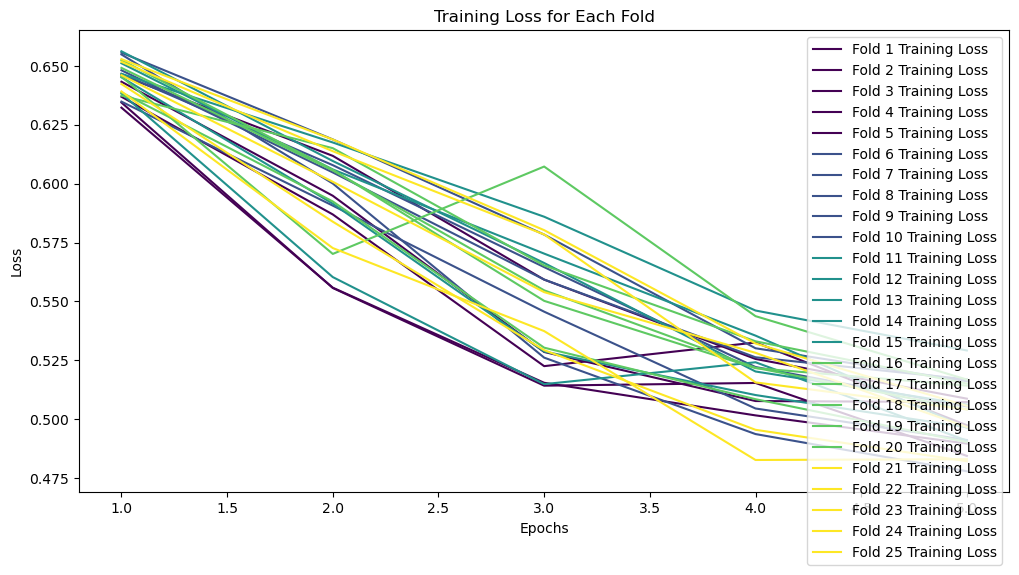

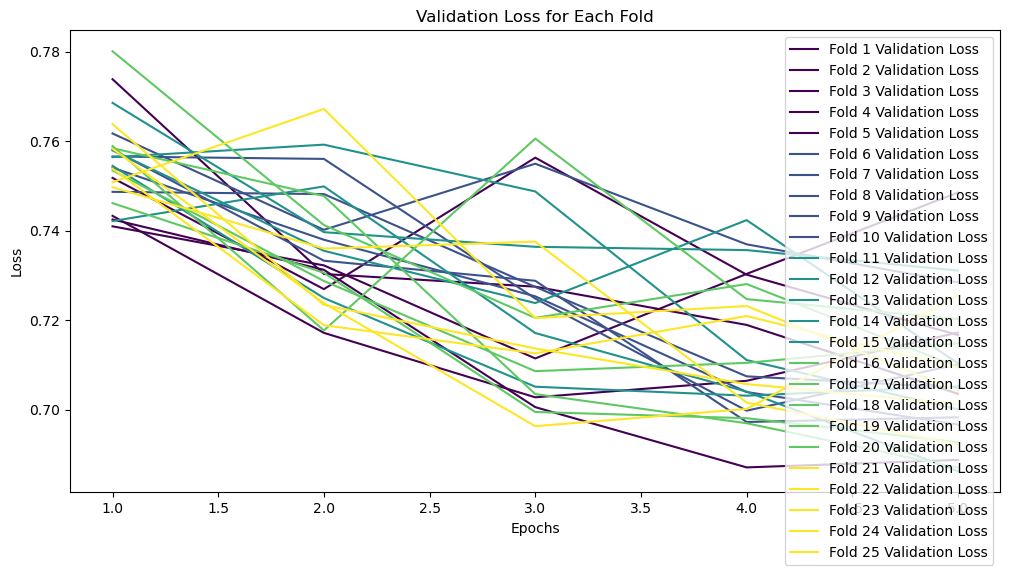

In [12]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm


plt.figure(figsize=(12, 6))
colors = cm.viridis(np.linspace(0, 1, 5))
for i, train_loss in enumerate(train_loss_list):
    plt.plot(
        range(1, len(train_loss) + 1),
        train_loss,
        label=f"Fold {i+1} Training Loss",
        color=colors[i // 5],
    )
plt.title("Training Loss for Each Fold")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.savefig("result/transformer_tabpfn_replace_train_loss.svg")
plt.show()

# Plot the validation loss for each fold
plt.figure(figsize=(12, 6))
for i, val_loss in enumerate(val_loss_list):
    plt.plot(
        range(1, len(val_loss) + 1),
        val_loss,
        label=f"Fold {i+1} Validation Loss",
        color=colors[i // 5],
    )
plt.title("Validation Loss for Each Fold")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.savefig("result/transformer_tabpfn_replace_val_loss.svg")
plt.show()